# IPAD Cycle-Aware SubspaceAD 실험 기록

Frozen baseline → 정상 LoRA 채택 → C/P ablation. 실행된 결과만 표시합니다.

## 설정과 실행

기본값은 분석 전용입니다. 학습 실행 시 RUN_STAGES에 원하는 단계를 넣습니다.

In [1]:
from pathlib import Path
import sys, subprocess, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd()/'configs').exists() else Path.cwd().parent
DATA_ROOT = ROOT.parent/'IPAD_dataset'
RUN_STAGES = []
for stage in RUN_STAGES:
    subprocess.run([sys.executable, '-m', 'ipad_experiment.pipeline', stage, '--data-root', str(DATA_ROOT)], cwd=ROOT, check=True)
print('Experiment root:', ROOT.name)

Experiment root: experiment


## 데이터와 규약

분할·제외 목록은 성능 계산 전에 고정합니다. 녹화 그룹과 실제 주기 경계는 미확인입니다.

In [2]:
display(pd.read_csv(ROOT/'results/00_prepare/data_counts.csv'))
display(pd.read_csv(ROOT/'results/00_prepare/exclusions.csv'))

,scene,partition,videos,frames
0,R01,final,9,2339
1,R01,development,6,1346
2,R01,validation,5,1125
3,R01,threshold,5,1144
4,R01,reference,5,1133
5,R01,fit,19,4406
6,R02,development,5,3209
7,R02,final,7,4497
8,R02,fit,17,10117
9,R02,threshold,4,2374


,id,frames,label_frames,reason
0,R02/testing/12,806,805,unresolved_frame_label_length_mismatch
1,R02/testing/13,609,608,unresolved_frame_label_length_mismatch
2,R02/testing/14,497,498,unresolved_frame_label_length_mismatch


## 실행 결과와 시각자료

개발셋과 최종셋은 별도 표기합니다. 미실행 결과를 수치로 채우지 않습니다.

00_prepare
No performance metrics for this stage.


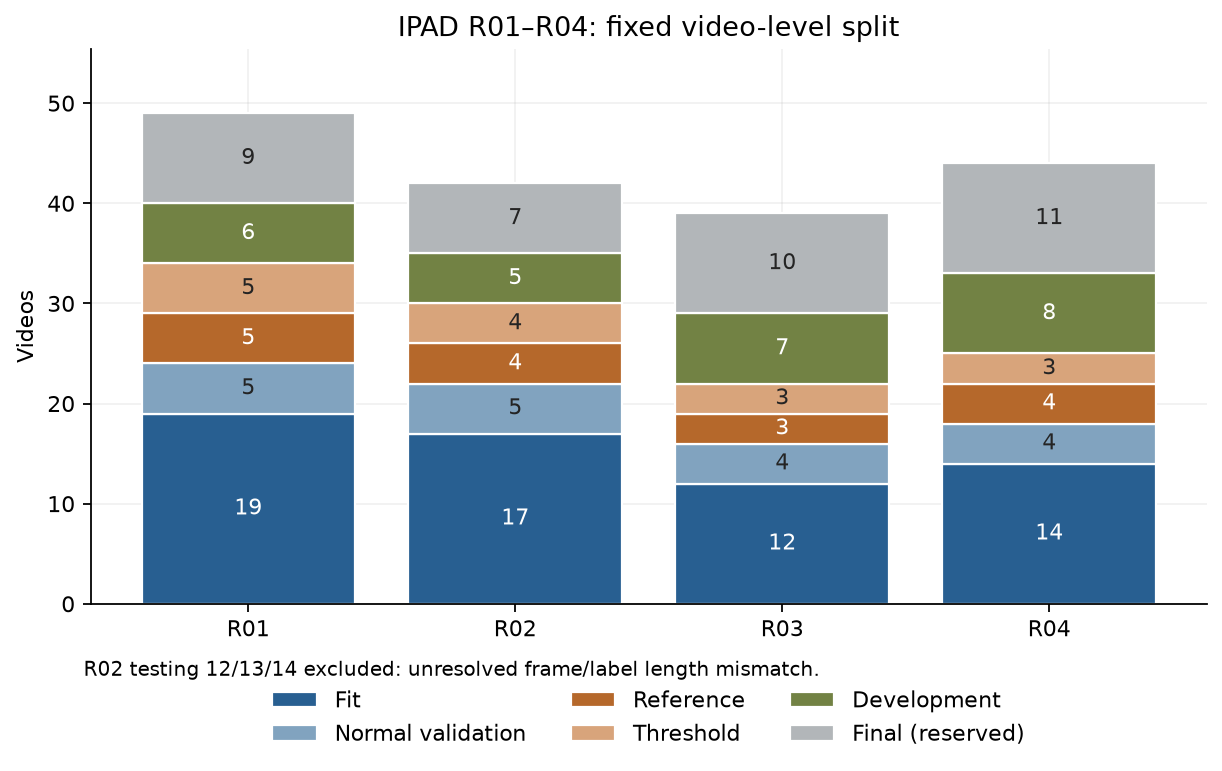

01_baseline


,scene,seed,branch,partition,threshold,auroc,ap,f1,tpr,fpr,frames,positive_frames,events,detected_events,event_coverage,delay_sum,mean_detected_event_delay_frames
0,R01,42,S,development,4.730921,0.656673,0.490963,0.183306,0.110891,0.059453,1346,505,3,3,1.000000,123,41.00
1,R02,42,S,development,4.394875,0.808093,0.664571,0.043518,0.022599,0.007918,3209,1062,5,2,0.400000,0,0.00
2,R03,42,S,development,2.242599,0.729861,0.768509,0.466371,0.307242,0.008880,4813,2223,6,4,0.666667,335,83.75
3,R04,42,S,development,13.199401,0.730513,0.594498,0.000000,0.000000,0.004705,3586,1673,13,0,0.000000,0,NaN


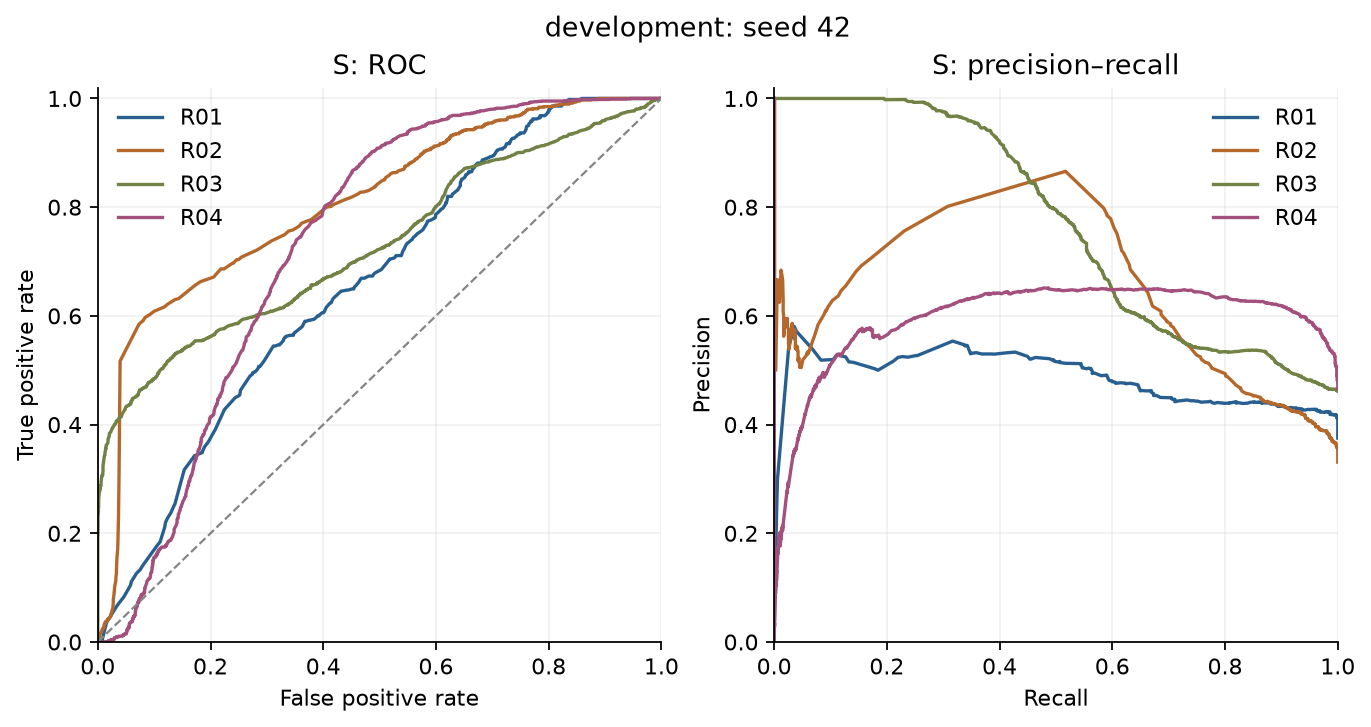

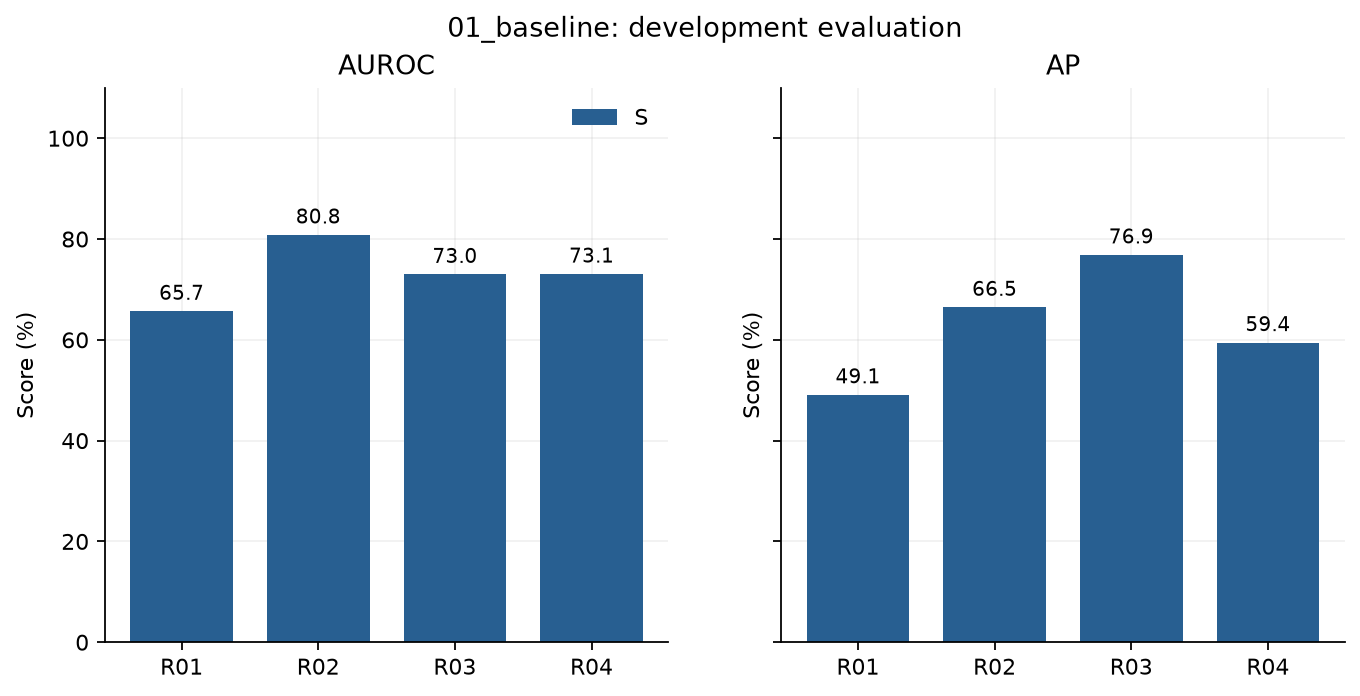

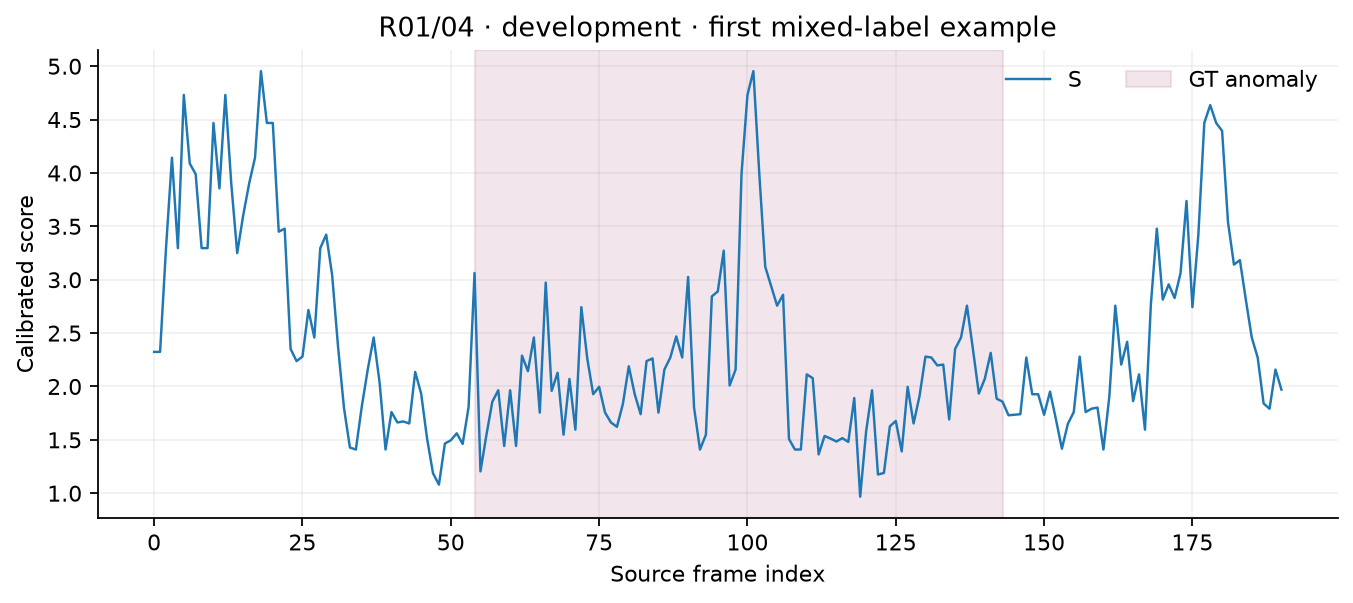

In [3]:
subprocess.run([sys.executable, '-m', 'ipad_experiment.pipeline', 'report'], cwd=ROOT, check=True)
for run in sorted((ROOT/'results').iterdir()):
    if not run.is_dir(): continue
    print(run.name)
    metric = run/'metrics_by_scene.csv'
    if metric.exists(): display(pd.read_csv(metric))
    else: print('No performance metrics for this stage.')
    for figure in sorted((run/'figures').glob('*.png')): display(Image(filename=str(figure)))

## 해석과 한계

각 단계의 report.md와 README는 실행된 로그·지표에서 작성합니다. 추정 cycle 좌표는 실제 위치 정답이 아닙니다. LoRA 채택은 고정된 개발셋 기준으로만 판단합니다.